# A tour of the qDGT–NTA experiments

This notebook follows the workflow in **Machine Learning-Enhanced DGT Passive Sampling Coupled with Non-Targeted Analysis for High-Throughput Monitoring of Chemical Pollutants in Aquatic Systems**. It uses the supplied spreadsheet, pretrained models, training feature arrays, and example inputs.

**Route:** experimental datasets → molecular features → model predictions → applicability domains → calibration and field validation → pollutant screening → reproducible figures.

Run the cells in order from the repository root. The notebook reads the original files and writes only the six figure PNGs if they are missing. It does not retrain the models or reproduce the original train/test split, which was not supplied.


## 0. Setup and source files

The package is installed with `pip install -e ".[notebook]"` (see the README). The next cell also supports opening this notebook from the `notebooks/` directory. All measurements and reported predictions below come from `supplementary file.xlsx` unless a cell explicitly calls a model.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "pyproject.toml").exists() and (p / "supplementary file.xlsx").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from the repository or a subdirectory")
sys.path.insert(0, str(ROOT / "src"))
WORKBOOK = ROOT / "supplementary file.xlsx"
FIGURES = ROOT / "figures"
print(f"Repository: {ROOT}")
print(f"Workbook: {WORKBOOK.name} ({WORKBOOK.stat().st_size / 1e6:.1f} MB)")


Repository: /app
Workbook: supplementary file.xlsx (5.1 MB)


In [2]:
from openpyxl import load_workbook
book = load_workbook(WORKBOOK, read_only=True, data_only=True)
display(pd.DataFrame(
    [(sheet.title, sheet.max_row, sheet.max_column) for sheet in book.worksheets],
    columns=["Supplement table", "Rows (including headers)", "Columns"]
))
book.close()


,Supplement table,Rows (including headers),Columns
0,Table S1,189,6
1,Table S2,6181,38
2,Table S3,1043,36
3,Table S4,14,5
4,Table S5,53,12
5,Table S6,27,4
6,Table S7,17,5
7,Table S8,41,7
8,Table S9,6,3
9,Table S10,33194,10


## 1. Experimental datasets

Tables S1–S3 contain diffusion coefficients and ionization efficiencies. Each row in an IE table represents a measurement under particular analytical conditions; the number of rows is therefore much larger than the number of distinct molecules. The code reads only the name, SMILES, and response columns needed for this overview.

In [3]:
d_data = pd.read_excel(WORKBOOK, sheet_name="Table S1", header=1)
pos_data = pd.read_excel(WORKBOOK, sheet_name="Table S2", header=1, usecols=[1, 2, 3])
neg_data = pd.read_excel(WORKBOOK, sheet_name="Table S3", header=1, usecols=[1, 2, 3])
summary = pd.DataFrame([
    ("Diffusion (S1)", d_data, "－logD"),
    ("Positive IE (S2)", pos_data, "logIE"),
    ("Negative IE (S3)", neg_data, "logIE"),
], columns=["Dataset", "Frame", "Response"])
summary["Measurements"] = summary.apply(lambda r: pd.to_numeric(r.Frame[r.Response], errors="coerce").notna().sum(), axis=1)
summary["Distinct SMILES"] = summary.Frame.map(lambda f: f["SMILES"].dropna().nunique())
display(summary[["Dataset", "Measurements", "Distinct SMILES"]])


,Dataset,Measurements,Distinct SMILES
0,Diffusion (S1),187,187
1,Positive IE (S2),3037,352
2,Negative IE (S3),1039,133


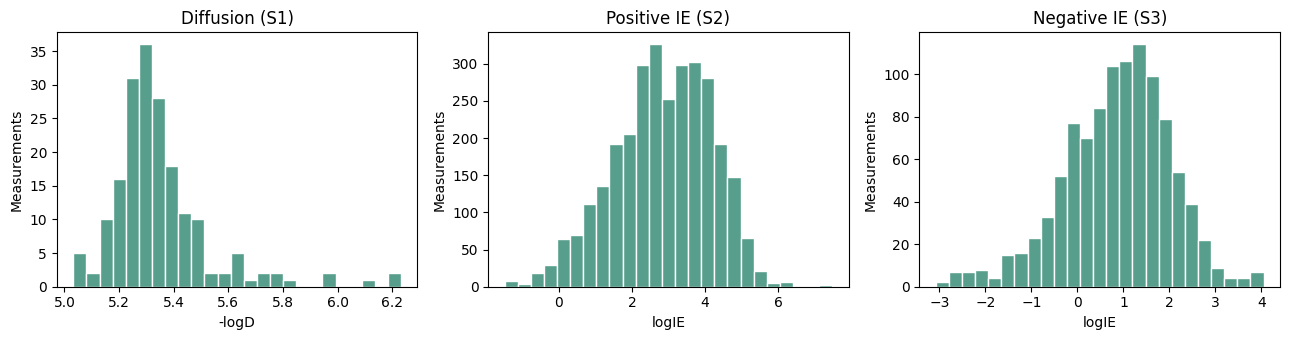

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (name, frame, response) in zip(axes, summary[["Dataset", "Frame", "Response"]].itertuples(index=False, name=None)):
    values = pd.to_numeric(frame[response], errors="coerce").dropna()
    ax.hist(values, bins=25, color="#579e8c", edgecolor="white")
    ax.set(title=name, xlabel=response.replace("－", "-"), ylabel="Measurements")
fig.tight_layout()
plt.show()


The three response distributions are descriptive views of the supplied tables. They are **not** model validation: repeated IE measurements can share one molecular structure while differing in instrument or mobile phase.

## 2. Feature contract and saved models

The bundled models use three different feature layouts. For −log D, molecular descriptors and fingerprints are concatenated. For logIE, molecular features are followed by the analytical condition columns shown in the corresponding example spreadsheet. The original implementation standardized each molecule's RDKit descriptor vector separately; the package retains this behavior so the saved models remain compatible.

In [5]:
import joblib
from qdgt_nta.features import generate_features
from qdgt_nta.predict import CONFIG
feature_rows = []
for kind, example_name in [
    ("d", "data example-for-D.xlsx"),
    ("pos", "data example-for-IE(+).xlsx"),
    ("neg", "data example-for-IE(-).xlsx"),
]:
    example = pd.read_excel(ROOT / "examples" / example_name)
    features = generate_features(example.loc[0, "SMILES"], kind)
    model_file, train_file, *_ = CONFIG[kind]
    model = joblib.load(ROOT / "assets" / "models" / model_file)
    train_shape = np.load(ROOT / "assets" / "train_features" / train_file, mmap_mode="r").shape
    condition_count = len(example.columns) - 2 if kind != "d" else 0
    feature_rows.append((kind, len(features), condition_count, model.n_features_in_, train_shape))
display(pd.DataFrame(feature_rows, columns=["Model", "Molecular features", "Condition columns", "Model input width", "AD training array shape"]))


,Model,Molecular features,Condition columns,Model input width,AD training array shape
0,d,2425,0,2425,"(149, 2425)"
1,pos,1823,32,1855,"(2429, 1855)"
2,neg,2637,16,2653,"(831, 2653)"


A matching input width confirms that the example conditions and computed features fit the saved model. It does not establish that the model is accurate for an arbitrary new chemical; the applicability domain check addresses part of that question.

## 3. Re-run the three pretrained models

These are **new inference calls**, made with the repository's four example rows for each model. `process_frame` returns predictions and AD flags while preserving the input rows. The IE examples include their instrument and eluent variables.

In [6]:
from qdgt_nta.predict import process_frame
predictions = {}
for kind, example_name in [
    ("d", "data example-for-D.xlsx"),
    ("pos", "data example-for-IE(+).xlsx"),
    ("neg", "data example-for-IE(-).xlsx"),
]:
    example = pd.read_excel(ROOT / "examples" / example_name)
    predictions[kind] = process_frame(example, kind, ad=True, root=ROOT)
    pred_column, ad_column = CONFIG[kind][2:4]
    print(f"{kind}: {pred_column} and {ad_column}")
    display(predictions[kind][["Name", "SMILES", pred_column, ad_column]])


d: Predicted_logD and in_AD_D


,Name,SMILES,Predicted_logD,in_AD_D
0,compound1,C=C1CCC2OC2(C)CCC2C1CC2(C)C,5.280388,False
1,compound2,CCC1OC(=O)C(C)C(OC2CC(C)(OC)C(O)C(C)O2)C(C)C(O...,5.588883,True
2,compound3,CCCCCCCCCCCC(O)CC(=O)O,5.201887,True
3,compound4,O=c1[nH]c2ccccc2s1,5.143573,True


pos: Predicted_logIE_POS and in_AD_IE(+)


,Name,SMILES,Predicted_logIE_POS,in_AD_IE(+)
0,compound1,Clc1ccc(COC(Cn2ccnc2)c2ccc(Cl)cc2Cl)c(Cl)c1,3.599148,True
1,compound2,c1ccc2[nH]c(-c3cscn3)nc2c1,2.817080,False
2,compound3,CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1,2.844257,True
3,compound4,CCCCCCCCCCCC[N+](C)(C)Cc1ccccc1,4.196463,True


neg: Predicted_logIE_neg and in_AD_IE(-)


,Name,SMILES,Predicted_logIE_neg,in_AD_IE(-)
0,compound1,C=C1CCC2OC2(C)CCC2C1CC2(C)C,0.343458,False
1,compound2,CCC1OC(=O)C(C)C(OC2CC(C)(OC)C(O)C(C)O2)C(C)C(O...,0.924072,True
2,compound3,CCCCCCCCCCCC(O)CC(=O)O,1.234871,True
3,compound4,O=c1[nH]c2ccccc2s1,-0.094953,False


The models predict `−logD`, `logIE(+)`, and `logIE(−)` in their training conventions. The AD flag is based on cosine similarity to the saved training feature arrays after scaling the combined training and candidate data. A `False` flag indicates extrapolation under the chosen threshold; it is not a statement that the compound cannot be detected.

### AD threshold sensitivity

The original scripts exposed similarity and neighbor-count thresholds. The refactored API applies overrides consistently. The following example uses the D dataset and varies only the similarity cutoff while holding the minimum neighbor count at one.

In [7]:
example_d = pd.read_excel(ROOT / "examples" / "data example-for-D.xlsx")
ad_columns = {}
for cutoff in (0.15, 0.35, 0.55):
    result = process_frame(example_d, "d", prediction=False, ad=True,
                           similarity=cutoff, count=1, root=ROOT)
    ad_columns[f"similarity ≥ {cutoff:.2f}"] = result["in_AD_D"].tolist()
ad_sensitivity = pd.DataFrame({"Name": example_d["Name"], **ad_columns})
display(ad_sensitivity)


,Name,similarity ≥ 0.15,similarity ≥ 0.35,similarity ≥ 0.55
0,compound1,False,False,False
1,compound2,True,True,True
2,compound3,True,False,False
3,compound4,True,True,False


## 4. Ionization response calibration

Table S5 pairs the model's predicted logIE values with measured logRF for 51 standards. Figure S7 visualizes this relation separately for positive and negative ionization. The lines below are least-squares fits to the **tabulated** values; they do not retrain the logIE models.

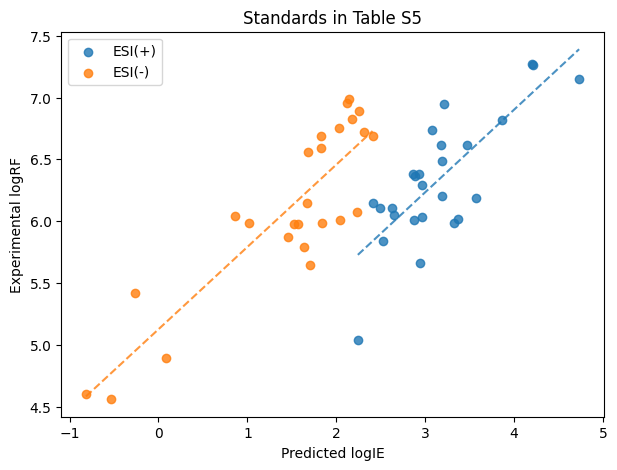

,Mode,n,Slope,Intercept,R²
0,ESI(+),26,0.668609,4.228025,0.604701
1,ESI(-),25,0.666159,5.125058,0.767739


In [8]:
standards = pd.read_excel(WORKBOOK, sheet_name="Table S5", header=1)
fig, ax = plt.subplots(figsize=(7, 5))
fit_rows = []
for mode, group in standards.groupby("Mode"):
    valid = group[["logIEpre", "logRF"]].apply(pd.to_numeric, errors="coerce").dropna()
    slope, intercept = np.polyfit(valid["logIEpre"], valid["logRF"], 1)
    fitted = slope * valid["logIEpre"] + intercept
    r2 = 1 - ((valid["logRF"] - fitted) ** 2).sum() / ((valid["logRF"] - valid["logRF"].mean()) ** 2).sum()
    points = ax.scatter(valid["logIEpre"], valid["logRF"], label=mode, alpha=.8)
    grid = np.linspace(valid["logIEpre"].min(), valid["logIEpre"].max(), 100)
    ax.plot(grid, slope * grid + intercept, "--", color=points.get_facecolor()[0])
    fit_rows.append((mode, len(valid), slope, intercept, r2))
ax.set(xlabel="Predicted logIE", ylabel="Experimental logRF", title="Standards in Table S5")
ax.legend(); plt.show()
display(pd.DataFrame(fit_rows, columns=["Mode", "n", "Slope", "Intercept", "R²"]))


## 5. Field-sample validation

Table S11 reports measured and predicted concentrations for 15 targeted compounds. We compare both aqueous concentration (`CS`, μg/L) and DGT concentration (`CDGT`, ng/L). The dashed line means perfect agreement. Fold error is `max(predicted / measured, measured / predicted)`; one is ideal.

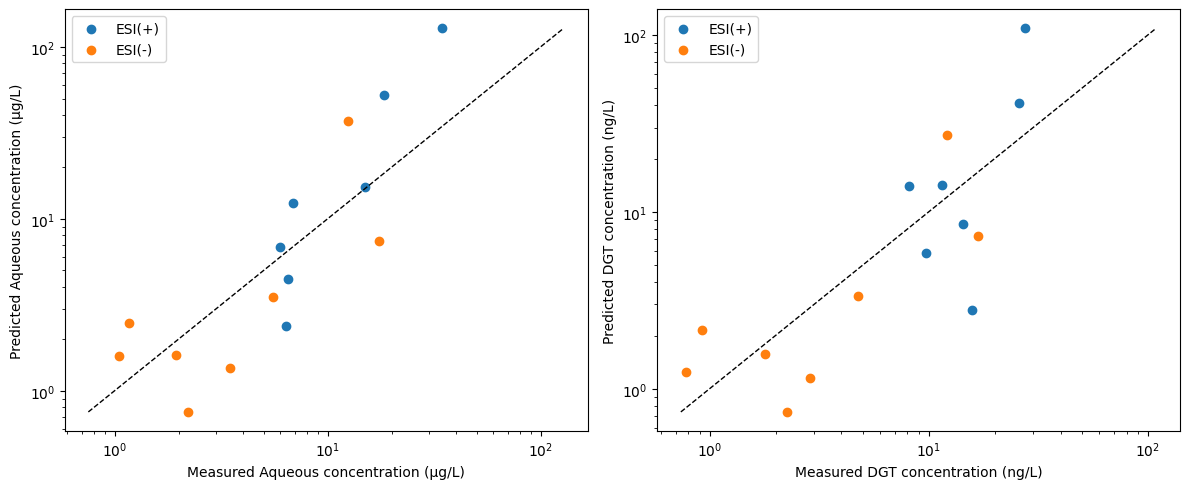

,Outcome,n,Median fold error,75th percentile fold error
0,Aqueous concentration (μg/L),15,2.112295,2.752574
1,DGT concentration (ng/L),15,1.723654,2.415858


In [9]:
validation = pd.read_excel(WORKBOOK, sheet_name="Table S11", header=1)
comparisons = [
    ("CS-exp (μg L-1)", "CS-pred (μg L-1)", "Aqueous concentration (μg/L)"),
    ("CDGT-exp (ng L-1)", "CDGT-pred (ng L-1)", "DGT concentration (ng/L)"),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
error_rows = []
for ax, (measured_col, predicted_col, label) in zip(axes, comparisons):
    numeric = validation[["Mode", measured_col, predicted_col]].copy()
    numeric[[measured_col, predicted_col]] = numeric[[measured_col, predicted_col]].apply(pd.to_numeric, errors="coerce")
    numeric = numeric.dropna()
    for mode, group in numeric.groupby("Mode"):
        ax.scatter(group[measured_col], group[predicted_col], label=mode)
    bounds = [numeric[[measured_col, predicted_col]].min().min(), numeric[[measured_col, predicted_col]].max().max()]
    ax.plot(bounds, bounds, "k--", linewidth=1)
    ax.set(xscale="log", yscale="log", xlabel=f"Measured {label}", ylabel=f"Predicted {label}")
    ax.legend()
    ratio = numeric[predicted_col] / numeric[measured_col]
    fold_error = np.maximum(ratio, 1 / ratio)
    error_rows.append((label, len(fold_error), np.median(fold_error), np.quantile(fold_error, .75)))
fig.tight_layout(); plt.show()
display(pd.DataFrame(error_rows, columns=["Outcome", "n", "Median fold error", "75th percentile fold error"]))


The plotted predictions here are the **reported values in Table S11**. Recreating them from raw chromatograms would require peak extraction, deployment details, response-factor calibration, and condition inputs beyond the example spreadsheets.

## 6. Applicability coverage of candidate pollutants

Table S10 records whether listed emerging contaminants are in the −logD, positive IE, and negative IE domains. This permits a direct count of compounds covered by both D and at least one IE model (Figure 3B). It does not provide the held-out predictions needed for Figure 3A.

In [10]:
coverage = pd.read_excel(WORKBOOK, sheet_name="Table S10", header=1,
                         usecols=["Classification", "In ADD", "In ADIE(+)", "In ADIE(-)"])
domain_d = coverage["In ADD"].eq(True)
domain_pos = coverage["In ADIE(+)"].eq(True)
domain_neg = coverage["In ADIE(-)"].eq(True)
coverage_counts = pd.Series({
    "−logD": int(domain_d.sum()),
    "logIE(+)": int(domain_pos.sum()),
    "logIE(−)": int(domain_neg.sum()),
    "D ∩ IE(+)": int((domain_d & domain_pos).sum()),
    "D ∩ IE(−)": int((domain_d & domain_neg).sum()),
    "D ∩ (IE(+) ∪ IE(−))": int((domain_d & (domain_pos | domain_neg)).sum()),
}, name="Compounds")
display(coverage_counts.to_frame())
print("Top classes in the joint D/IE coverage:")
display(coverage.loc[domain_d & (domain_pos | domain_neg), "Classification"].value_counts().head(10).rename("Compounds").to_frame())


,Compounds
−logD,33192
logIE(+),18695
logIE(−),12543
D ∩ IE(+),18695
D ∩ IE(−),12543
D ∩ (IE(+) ∪ IE(−)),22530


Top classes in the joint D/IE coverage:


,Compounds
Classification,
Benzene and substituted derivatives,5829
Organooxygen compounds,1991
Carboxylic acids and derivatives,1671
Fatty Acyls,1446
Organonitrogen compounds,1027
Steroids and steroid derivatives,891
Naphthalenes,707
Phenols,541
Pyridines and derivatives,501


## 7. Pollutants identified in DGT samples

Tables S14–S15 hold the paper's predicted concentrations for compounds detected in positive and negative ion modes. The next cell ranks the highest predicted DGT concentrations and counts entries by chemical class. These are **published table values**, not fresh inference calls.

In [11]:
detected = []
for sheet, mode in [("Table S14", "ESI+"), ("Table S15", "ESI−")]:
    frame = pd.read_excel(WORKBOOK, sheet_name=sheet, header=1)
    frame["Mode"] = mode
    detected.append(frame)
detected = pd.concat(detected, ignore_index=True)
detected["Predicted CDGT (ngL-1)"] = pd.to_numeric(detected["Predicted CDGT (ngL-1)"], errors="coerce")
detected = detected.dropna(subset=["Name", "Predicted CDGT (ngL-1)"])
print(f"Detected compounds: {len(detected)}")
display(detected[["Name", "Class", "Mode", "Predicted CDGT (ngL-1)"]]
        .sort_values("Predicted CDGT (ngL-1)", ascending=False).head(12))
display(pd.crosstab(detected["Class"], detected["Mode"]).sort_values("ESI+", ascending=False).head(10))


Detected compounds: 85


,Name,Class,Mode,Predicted CDGT (ngL-1)
23,Galaxolidone,Transformation Products,ESI+,9976.947505
22,Hexadecanamide,Personal Care Products,ESI+,3391.812034
15,N-Butylbenzenesulfonamide,Functional Additives,ESI+,2847.550912
37,4-Formylaminoantipyrine,Transformation Products,ESI+,2486.634562
64,8-(4-Sulfophenyl) octanoic acid,Others,ESI−,1580.613380
39,"3,5-di-tert-Butyl-4-hydroxybenzoic acid",Transformation Products,ESI+,1566.938692
31,Carbendazim,Pesticides,ESI+,1530.285101
59,4-Dodecylbenzenesulfonic acid,Functional Additives,ESI−,1352.932418
18,"Methyl 3,5-di-tert-butyl-4-hydroxybenzoate",Functional Additives,ESI+,1298.079047
25,Estriol,Pharmaceuticals,ESI+,890.910376


Mode,ESI+,ESI−
Class,,
Pharmaceuticals,14,6
Transformation Products,7,6
Functional Additives,6,10
Natural Products,5,8
Pesticides,4,1
Others,3,4
Personal Care Products,3,0
Industrial Materials,1,7


## 8. Recreate the data-supported figures

The plotting module generates six PNGs from the supplementary tables: Figures 3B, 4A, a readable top-25 subset of Figure 5, and Figures S1, S7, and S8. Existing PNGs are reused. The paper's exact visual design and panels requiring unavailable model splits are outside this notebook's reproducible scope.

figure_s1_distributions.png


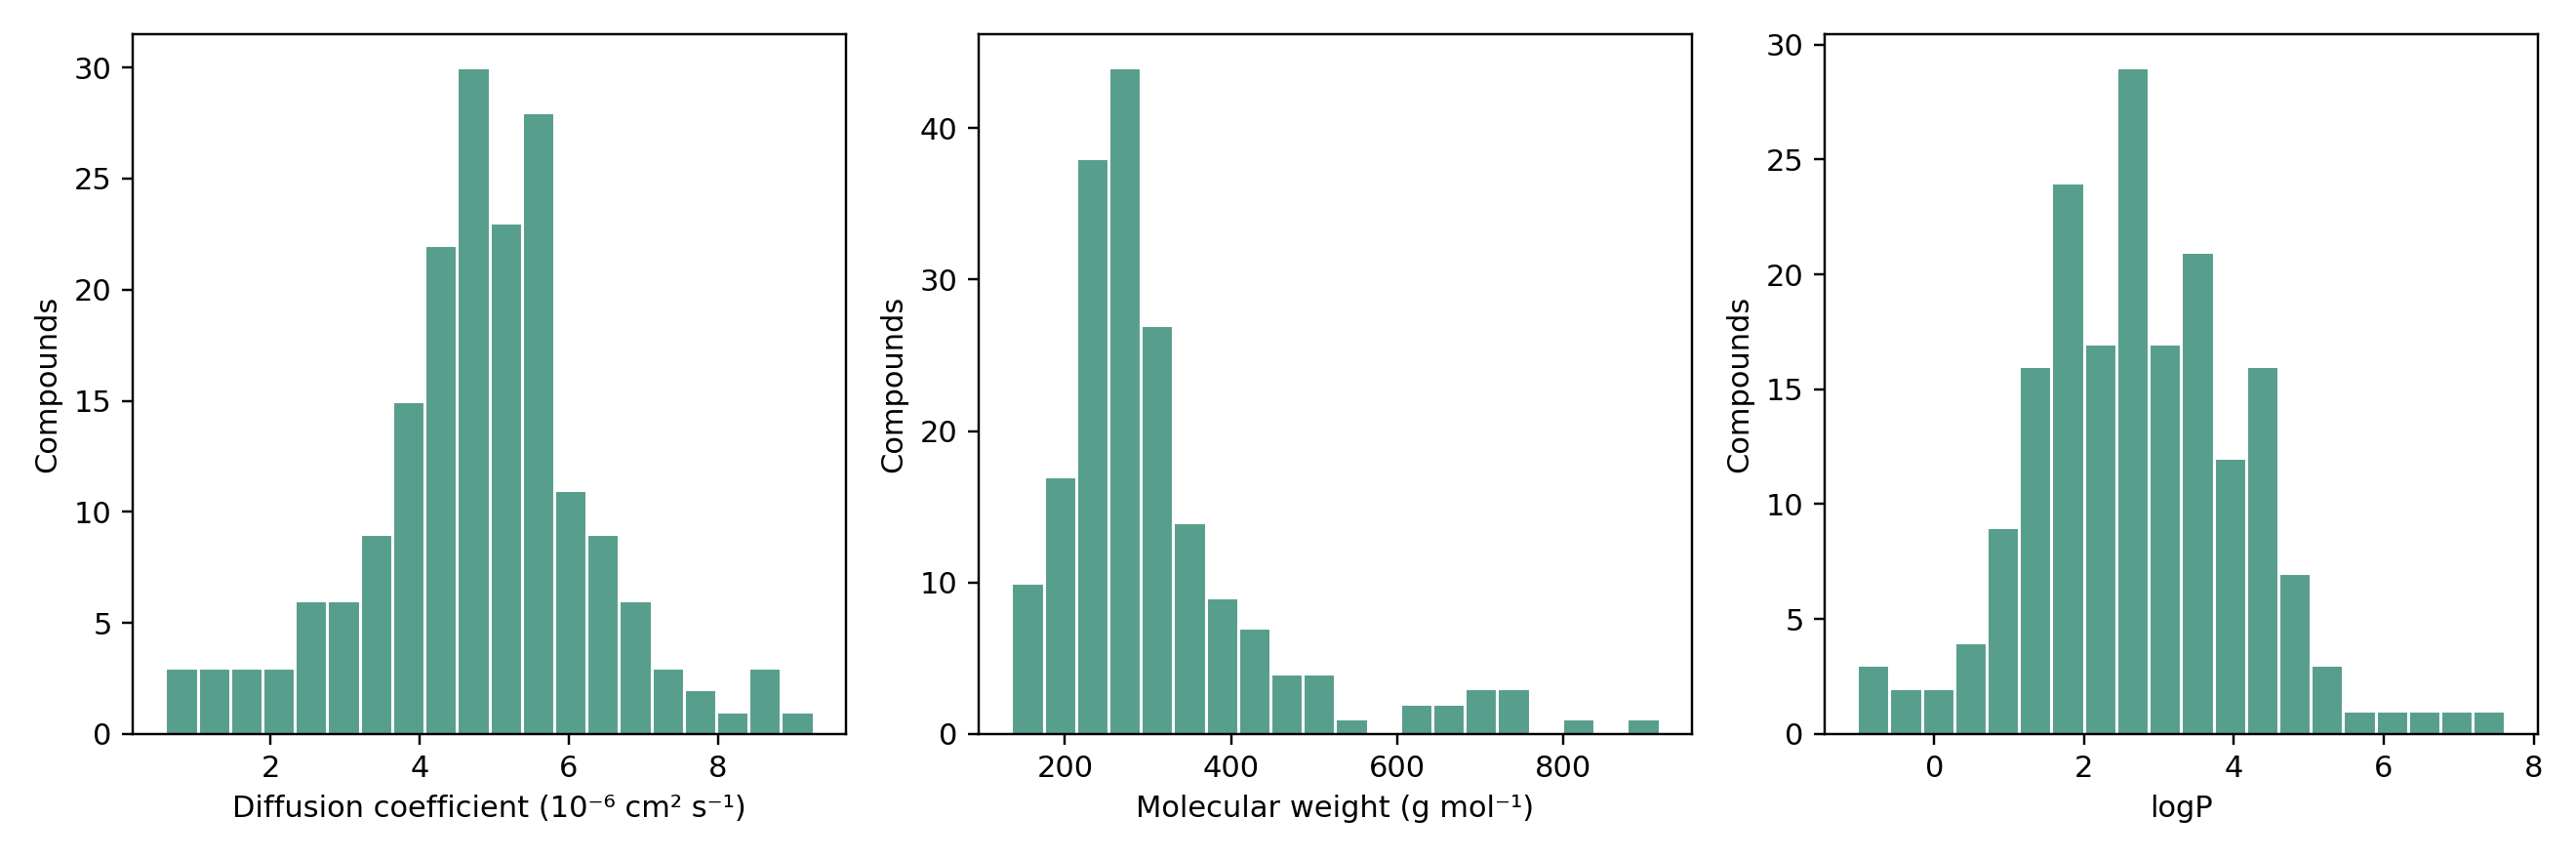

figure_s7_ie_rf.png


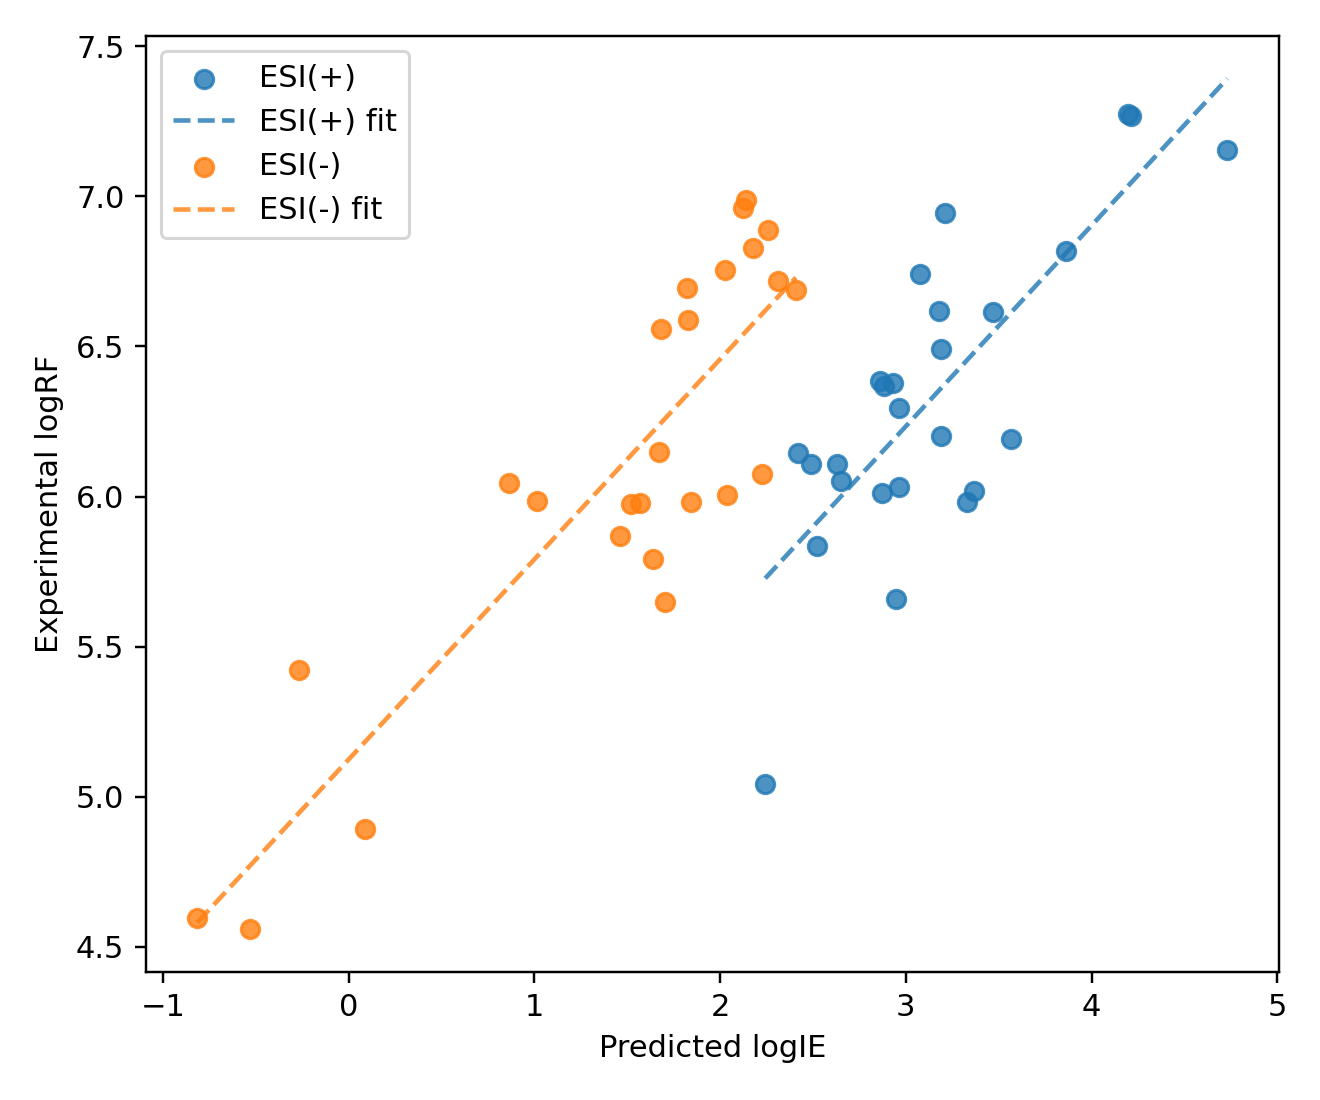

figure_3b_ad_coverage.png


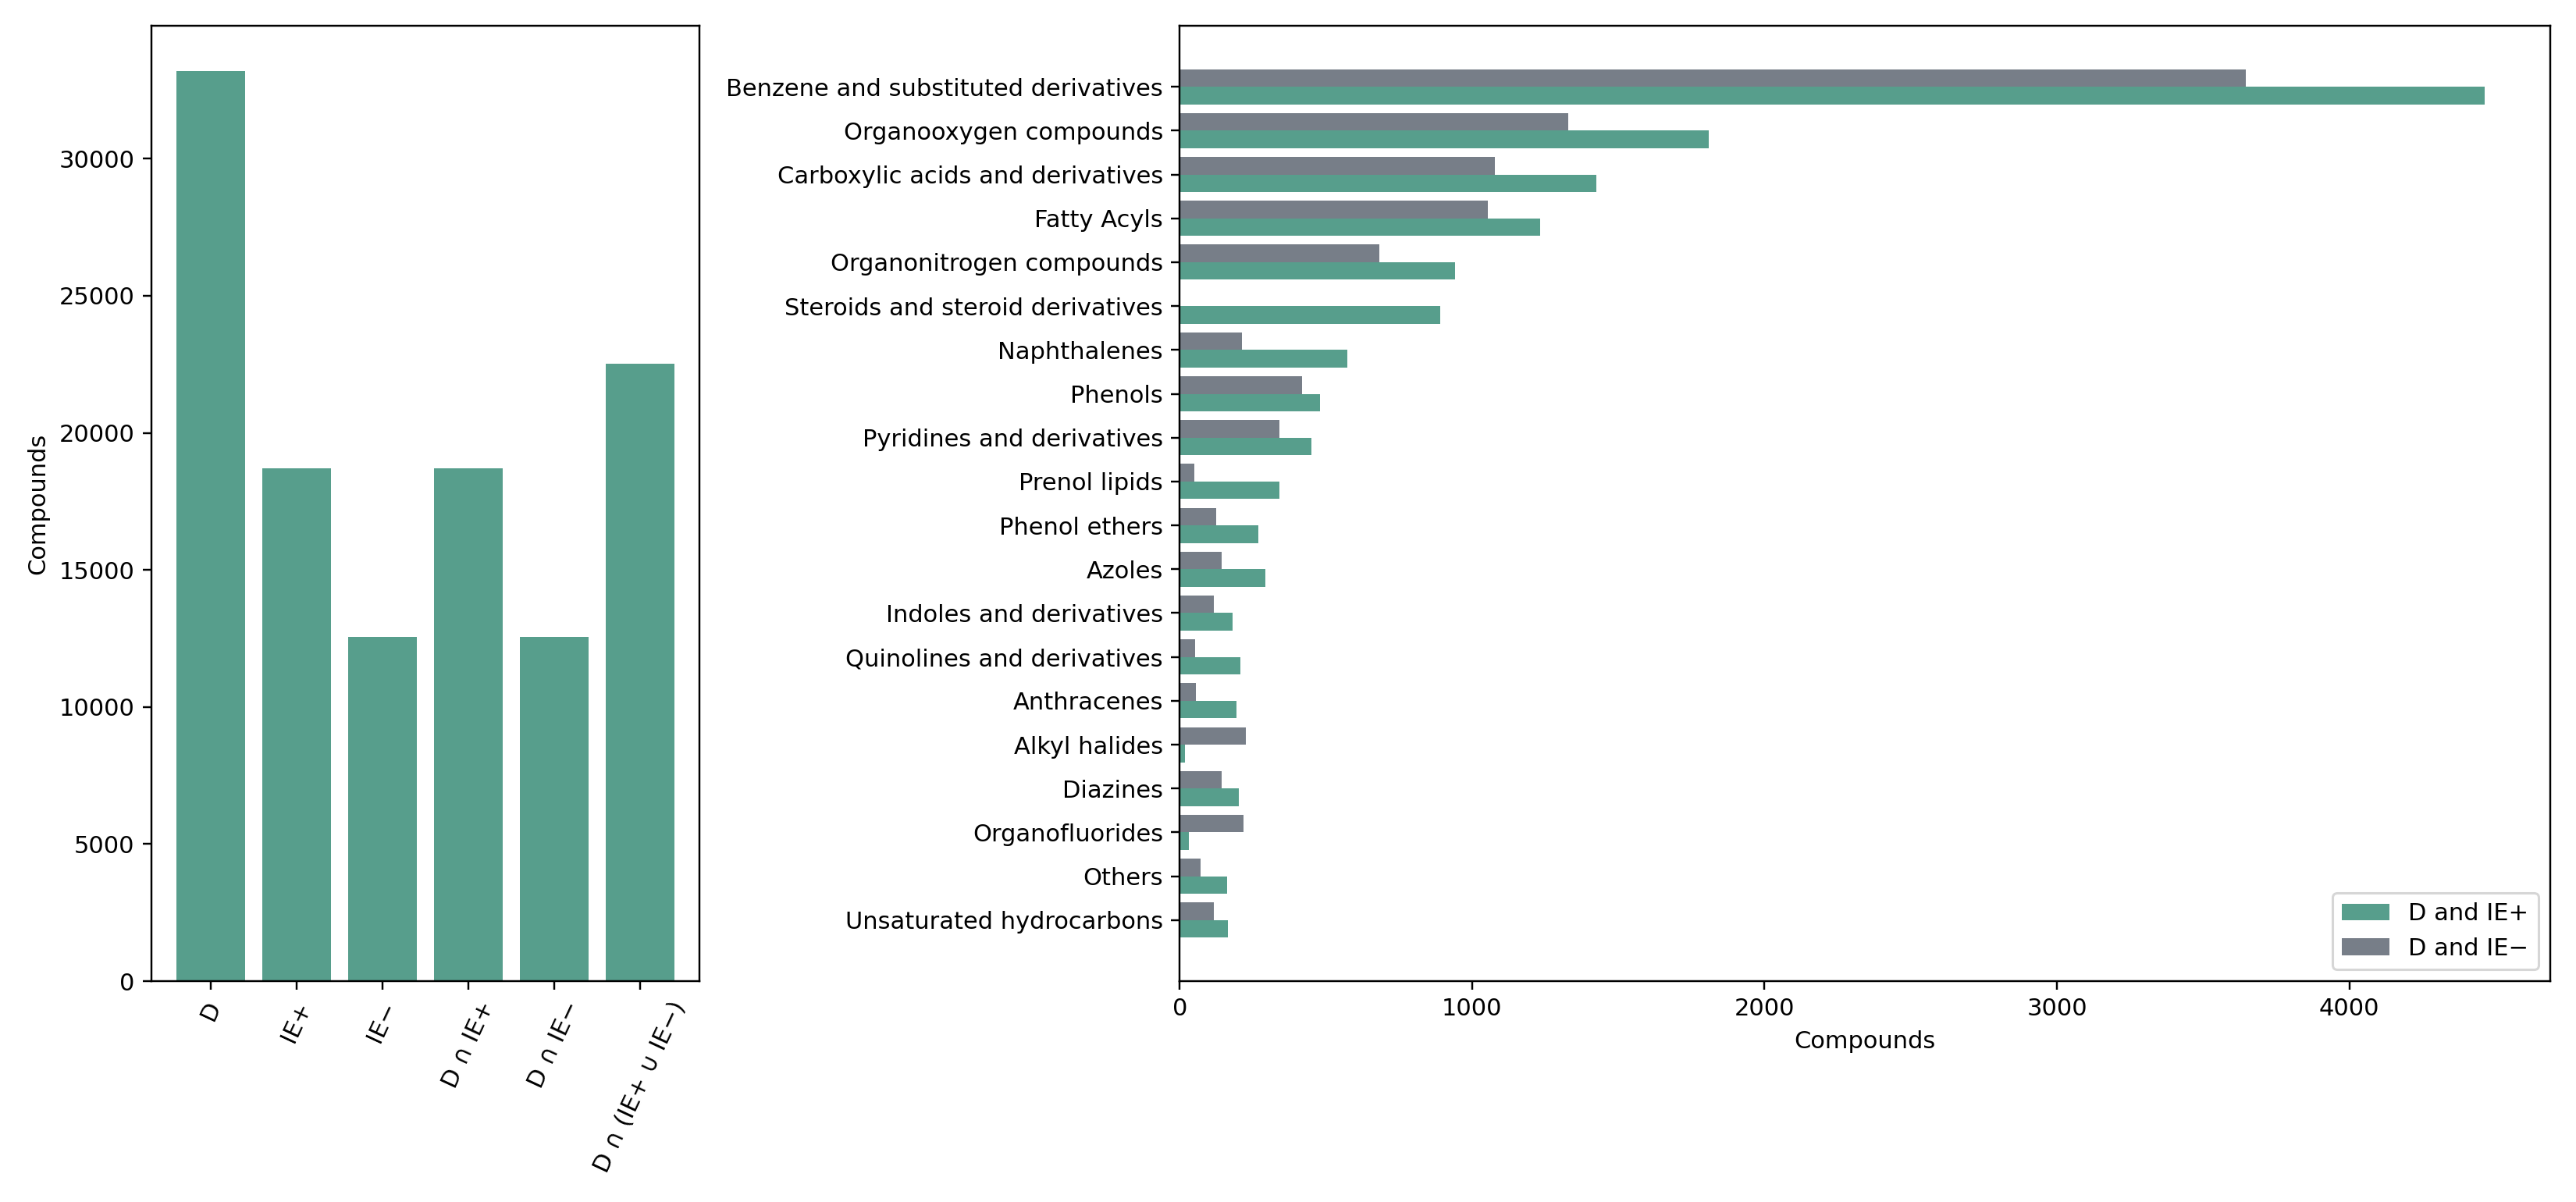

figure_4a_validation.png


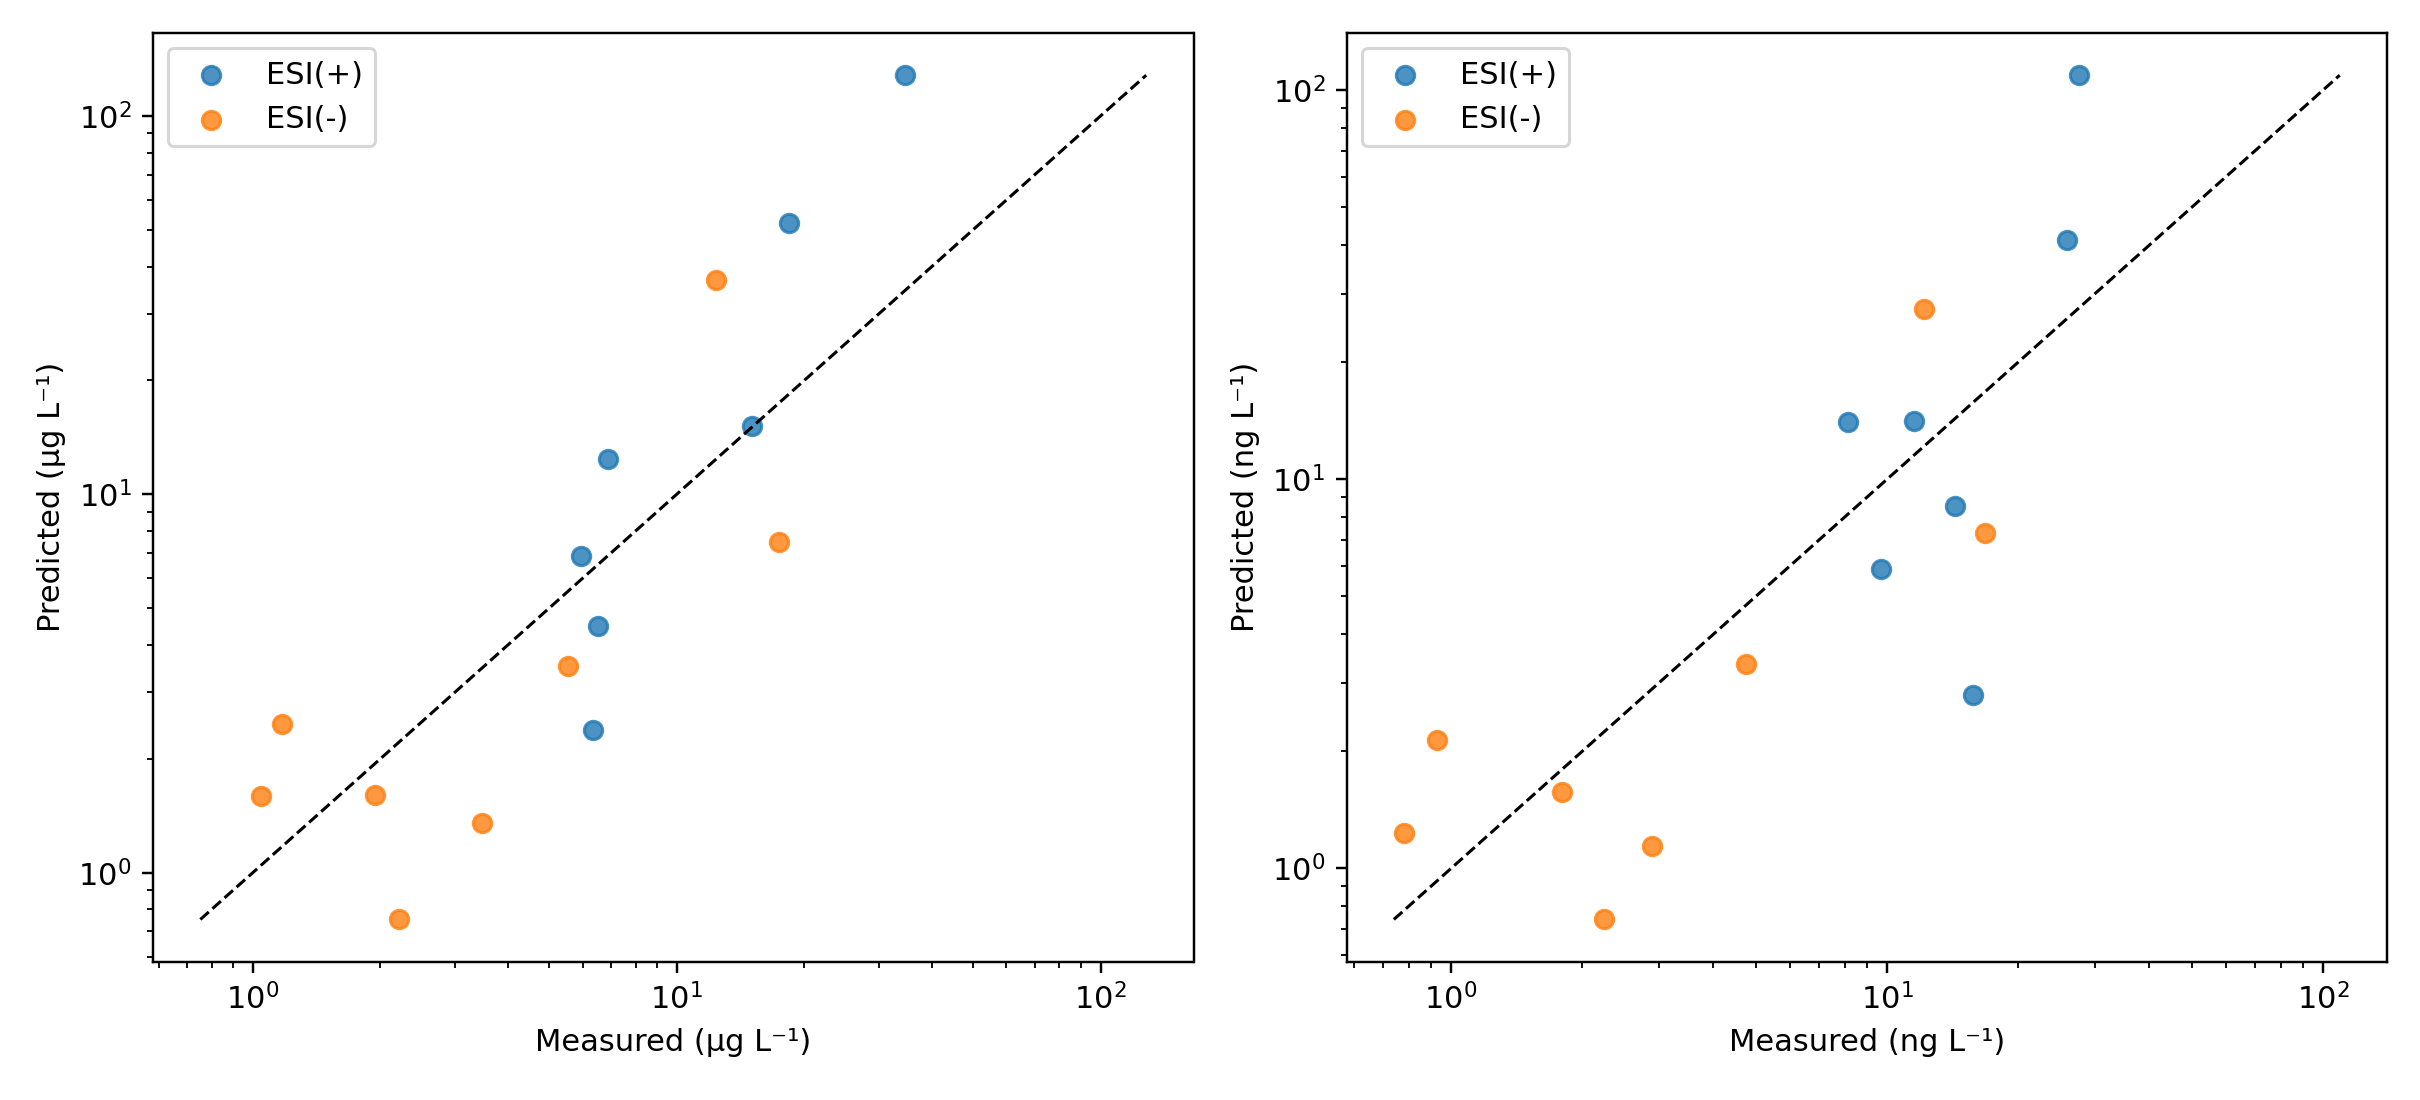

figure_5_predicted_concentrations.png


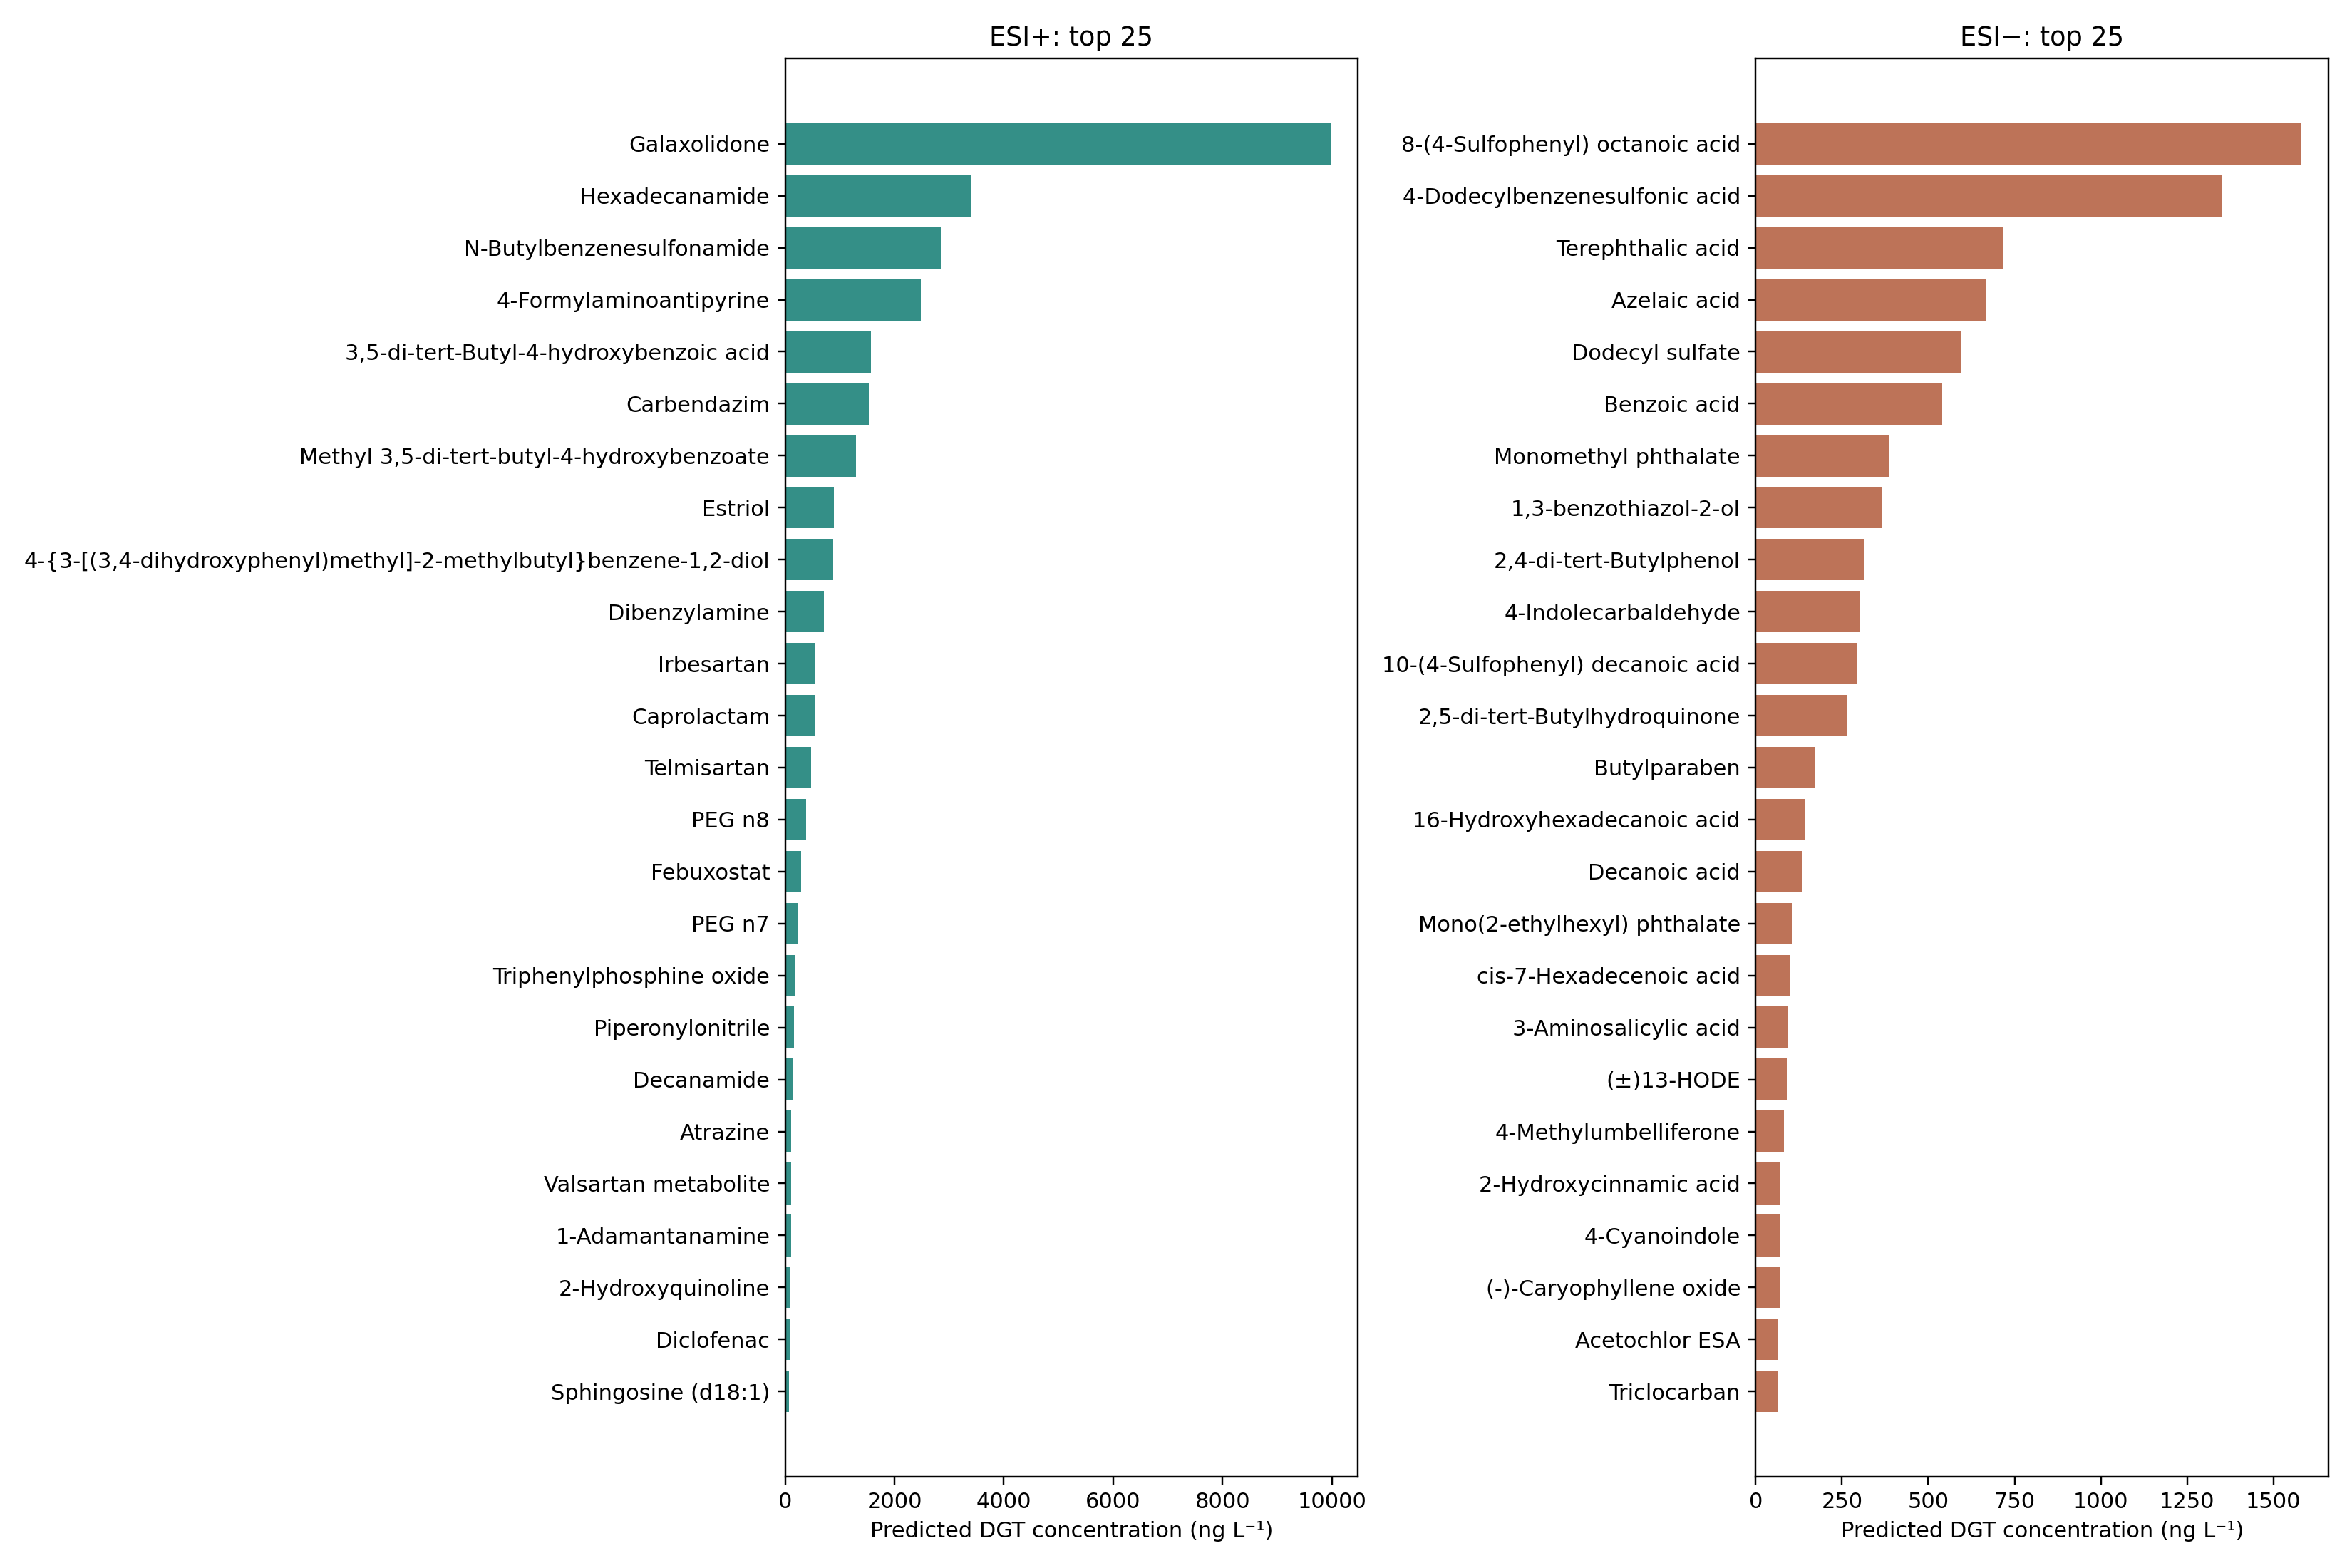

figure_s8_fold_errors.png


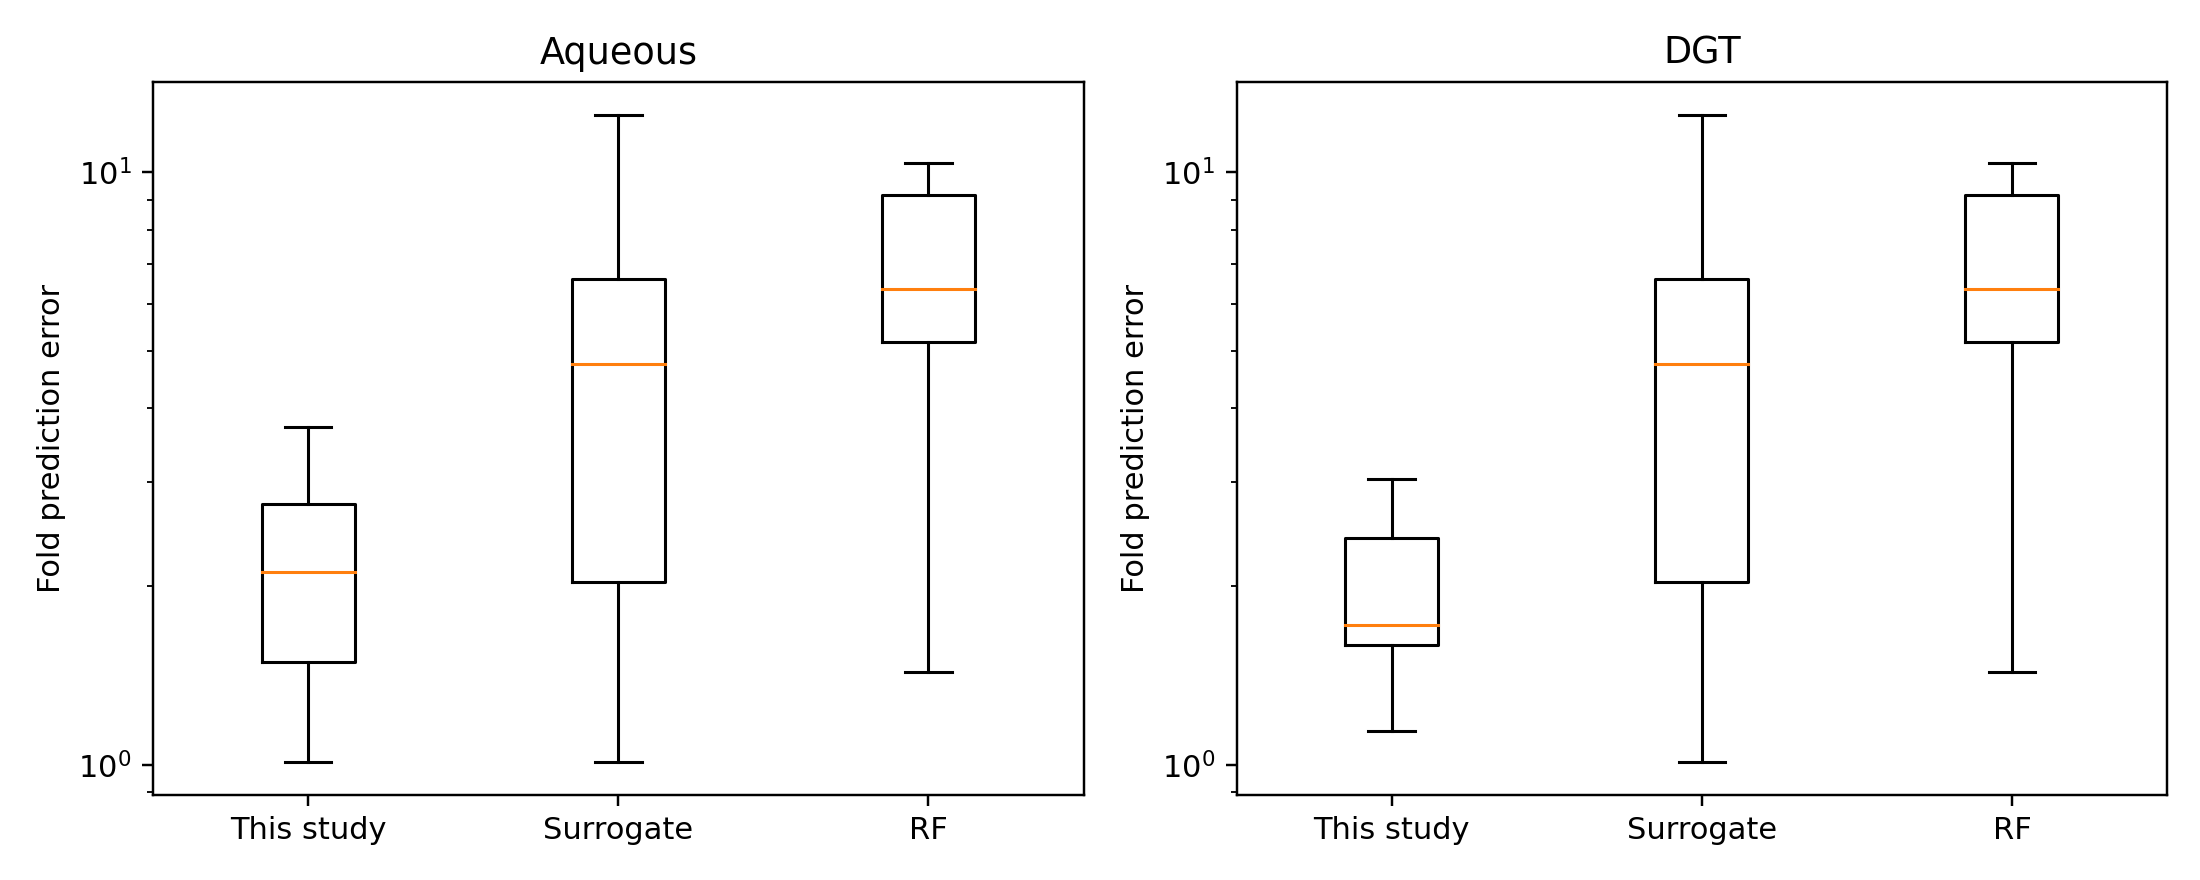

In [12]:
from qdgt_nta.figures import create_figures
expected = [
    "figure_s1_distributions.png", "figure_s7_ie_rf.png",
    "figure_3b_ad_coverage.png", "figure_4a_validation.png",
    "figure_5_predicted_concentrations.png", "figure_s8_fold_errors.png",
]
if any(not (FIGURES / name).exists() for name in expected):
    print("Generating figures from the workbook; this can take about a minute...")
    create_figures(WORKBOOK, FIGURES)
for name in expected:
    print(name)
    display(Image(filename=str(FIGURES / name), width=800))


## What this tour does and does not establish

- **Reproduced from source tables:** dataset sizes and distributions, logIE–logRF fits, field-validation comparisons, AD coverage counts, and concentration summaries.
- **Recomputed with pretrained artifacts:** example predictions, feature dimensions, AD flags, and threshold sensitivity.
- **Unavailable for exact reproduction:** original model training and optimization, held-out splits, bootstrap predictions, raw LC–MS peak extraction, and the source data/settings for some structural-space panels.

For new compounds, start with the example sheet matching the desired model. Preserve the IE condition column order, inspect the AD flag, and report the model and thresholds alongside any prediction.